# VAD Clustering Analysis

This notebook performs clustering analysis on the baseline VAD scores using DBSCAN and visualizes the results in 3D space.

## Overview
- Load baseline VAD scores from CSV
- Apply DBSCAN clustering algorithm
- Visualize clusters in 3D VAD space
- Analyze cluster characteristics and sample sentences


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import seaborn as sns

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully")


Libraries imported successfully


## Load Baseline VAD Scores


In [4]:
# Load the baseline VAD scores
df = pd.read_csv('../Datasets/baseline_vad_scores.csv')

print(f"Loaded {len(df)} sentences with VAD scores")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
print(df.head())

print("\nVAD Score Statistics:")
print(df[['valence', 'arousal', 'dominance']].describe())


Loaded 159 sentences with VAD scores
Columns: ['sentence', 'valence', 'arousal', 'dominance']

First few rows:
                                            sentence  valence  arousal  \
0  OMG, just watched that new Marvel flick, total...   0.3003   0.0685   
1  Life's gr8, scored tickets to Taylor Swift con...   0.5294   0.3266   
2  Yo, promotion at work finally, feelin like a b...   0.3280   0.0655   
3  Chillin with fam on vacation, beach vibes, tot...   0.3707  -0.1517   
4  Quiet prayer time, feelin blessed and peaceful...   0.2416  -0.2438   

   dominance  
0     0.2343  
1     0.3410  
2     0.2862  
3     0.0838  
4     0.0970  

VAD Score Statistics:
          valence     arousal   dominance
count  159.000000  159.000000  159.000000
mean     0.023165    0.084619    0.056604
std      0.315041    0.241627    0.195057
min     -0.565500   -0.901000   -0.647800
25%     -0.189850   -0.099150   -0.066100
50%     -0.014200    0.099800    0.063000
75%      0.257350    0.275850    0.20

## Prepare Data for Clustering


In [7]:
# Extract VAD features for clustering
vad_features = df[['valence', 'arousal', 'dominance']].values

# Standardize the features for DBSCAN
scaler = StandardScaler()
vad_scaled = scaler.fit_transform(vad_features)

print("VAD features shape:", vad_features.shape)
print("Scaled features shape:", vad_scaled.shape)
print("\nOriginal VAD ranges:")
print(f"Valence: [{vad_features[:, 0].min():.3f}, {vad_features[:, 0].max():.3f}]")
print(f"Arousal: [{vad_features[:, 1].min():.3f}, {vad_features[:, 1].max():.3f}]")
print(f"Dominance: [{vad_features[:, 2].min():.3f}, {vad_features[:, 2].max():.3f}]")

print("\nScaled VAD ranges:")
print(f"Valence: [{vad_scaled[:, 0].min():.3f}, {vad_scaled[:, 0].max():.3f}]")
print(f"Arousal: [{vad_scaled[:, 1].min():.3f}, {vad_scaled[:, 1].max():.3f}]")
print(f"Dominance: [{vad_scaled[:, 2].min():.3f}, {vad_scaled[:, 2].max():.3f}]")


VAD features shape: (159, 3)
Scaled features shape: (159, 3)

Original VAD ranges:
Valence: [-0.566, 0.824]
Arousal: [-0.901, 0.563]
Dominance: [-0.648, 0.467]

Scaled VAD ranges:
Valence: [-1.874, 2.551]
Arousal: [-4.092, 1.984]
Dominance: [-3.623, 2.108]


## Apply DBSCAN Clustering


In [10]:
# Apply DBSCAN clustering
# eps: maximum distance between two samples for one to be considered as in the neighborhood of the other
# min_samples: number of samples in a neighborhood for a point to be considered as a core point
dbscan = DBSCAN(eps=0.5, min_samples=5, metric='euclidean')
cluster_labels = dbscan.fit_predict(vad_scaled)

# Add cluster labels to dataframe
df['cluster'] = cluster_labels

# Analyze clustering results
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Number of core samples: {len(dbscan.core_sample_indices_)}")

# Calculate silhouette score (excluding noise points)
if n_clusters > 1:
    # Only calculate silhouette score for non-noise points
    non_noise_mask = cluster_labels != -1
    if np.sum(non_noise_mask) > 1:
        silhouette_avg = silhouette_score(vad_scaled[non_noise_mask], 
                                        cluster_labels[non_noise_mask])
        print(f"Average silhouette score: {silhouette_avg:.3f}")

# Show cluster distribution
print("\nCluster distribution:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    if cluster_id == -1:
        print(f"Noise points: {count}")
    else:
        print(f"Cluster {cluster_id}: {count} points")


Number of clusters: 4
Number of noise points: 69
Number of core samples: 55
Average silhouette score: 0.269

Cluster distribution:
Noise points: 69
Cluster 0: 10 points
Cluster 1: 13 points
Cluster 2: 57 points
Cluster 3: 10 points


## 3D Visualization of Clusters


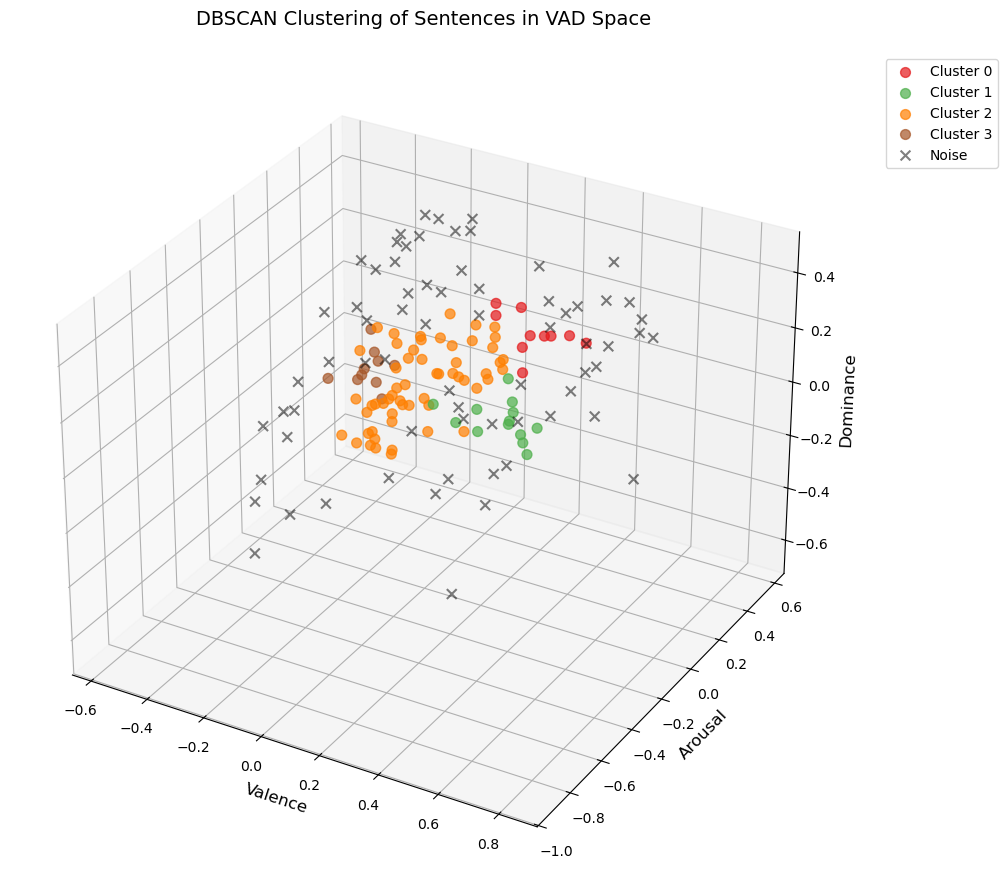

3D visualization shows 4 clusters and 69 noise points


In [13]:
# Create 3D scatter plot of clusters in VAD space
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Define colors for clusters
unique_labels = set(cluster_labels)
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))

# Plot each cluster
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Noise points in black
        col = 'black'
        marker = 'x'
        alpha = 0.5
        label = 'Noise'
    else:
        marker = 'o'
        alpha = 0.7
        label = f'Cluster {k}'
    
    class_member_mask = (cluster_labels == k)
    xy = vad_features[class_member_mask]
    
    ax.scatter(xy[:, 0], xy[:, 1], xy[:, 2], 
              c=[col], marker=marker, alpha=alpha, s=50, label=label)

# Customize the plot
ax.set_xlabel('Valence', fontsize=12)
ax.set_ylabel('Arousal', fontsize=12)
ax.set_zlabel('Dominance', fontsize=12)
ax.set_title('DBSCAN Clustering of Sentences in VAD Space', fontsize=14, pad=20)

# Add legend
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"3D visualization shows {n_clusters} clusters and {n_noise} noise points")


## Cluster Analysis and Sample Sentences


In [16]:
# Analyze each cluster and show sample sentences
def analyze_cluster(cluster_id, df, n_samples=3):
    """Analyze a cluster and show sample sentences"""
    if cluster_id == -1:
        cluster_data = df[df['cluster'] == cluster_id]
        print(f"\n=== NOISE POINTS ({len(cluster_data)} sentences) ===")
    else:
        cluster_data = df[df['cluster'] == cluster_id]
        print(f"\n=== CLUSTER {cluster_id} ({len(cluster_data)} sentences) ===")
    
    if len(cluster_data) == 0:
        print("No sentences in this cluster")
        return
    
    # Calculate cluster statistics
    vad_stats = cluster_data[['valence', 'arousal', 'dominance']].describe()
    print("\nVAD Statistics:")
    print(f"Valence: mean={vad_stats.loc['mean', 'valence']:.3f}, std={vad_stats.loc['std', 'valence']:.3f}")
    print(f"Arousal:  mean={vad_stats.loc['mean', 'arousal']:.3f}, std={vad_stats.loc['std', 'arousal']:.3f}")
    print(f"Dominance: mean={vad_stats.loc['mean', 'dominance']:.3f}, std={vad_stats.loc['std', 'dominance']:.3f}")
    
    # Show sample sentences
    print(f"\nSample sentences (showing {min(n_samples, len(cluster_data))}):")
    samples = cluster_data.sample(min(n_samples, len(cluster_data)), random_state=42)
    
    for idx, (_, row) in enumerate(samples.iterrows(), 1):
        sentence = row['sentence']
        # Truncate long sentences for display
        if len(sentence) > 80:
            sentence = sentence[:77] + "..."
        print(f"{idx}. V={row['valence']:.3f}, A={row['arousal']:.3f}, D={row['dominance']:.3f}")
        print(f"   \"{sentence}\"")

# Analyze all clusters
unique_clusters = sorted(df['cluster'].unique())
for cluster_id in unique_clusters:
    analyze_cluster(cluster_id, df, n_samples=4)



=== NOISE POINTS (69 sentences) ===

VAD Statistics:
Valence: mean=0.024, std=0.396
Arousal:  mean=0.133, std=0.307
Dominance: mean=0.083, std=0.255

Sample sentences (showing 4):
1. V=-0.478, A=0.425, D=-0.011
   "Fear consumin bout pandemic return, hidin."
2. V=0.529, A=0.327, D=0.341
   "Life's gr8, scored tickets to Taylor Swift concert, dancin all nite, ownin my..."
3. V=-0.134, A=0.444, D=0.362
   "Angry power dominant yell at rally."
4. V=0.470, A=0.333, D=0.467
   "Got engaged, ecstatic, energy max, boss of my love life!"

=== CLUSTER 0 (10 sentences) ===

VAD Statistics:
Valence: mean=0.322, std=0.098
Arousal:  mean=0.102, std=0.060
Dominance: mean=0.276, std=0.039

Sample sentences (showing 4):
1. V=0.243, A=0.169, D=0.315
   "Hyped for political rally, energy high, we own this!"
2. V=0.328, A=0.066, D=0.286
   "Yo, promotion at work finally, feelin like a boss, energy thru the roof, time..."
3. V=0.189, A=0.108, D=0.299
   "Anxiety peakin over family secrets, submittin full

## Additional Visualizations


/var/folders/pj/88mbw0h90rv6cb568zh6r3nr0000gn/T/ipykernel_20087/3200871988.py:22: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(vad_features[mask, 0], vad_features[mask, 1],
/var/folders/pj/88mbw0h90rv6cb568zh6r3nr0000gn/T/ipykernel_20087/3200871988.py:38: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax2.scatter(vad_features[mask, 0], vad_features[mask, 2],
/var/folders/pj/88mbw0h90rv6cb568zh6r3nr0000gn/T/ipyke

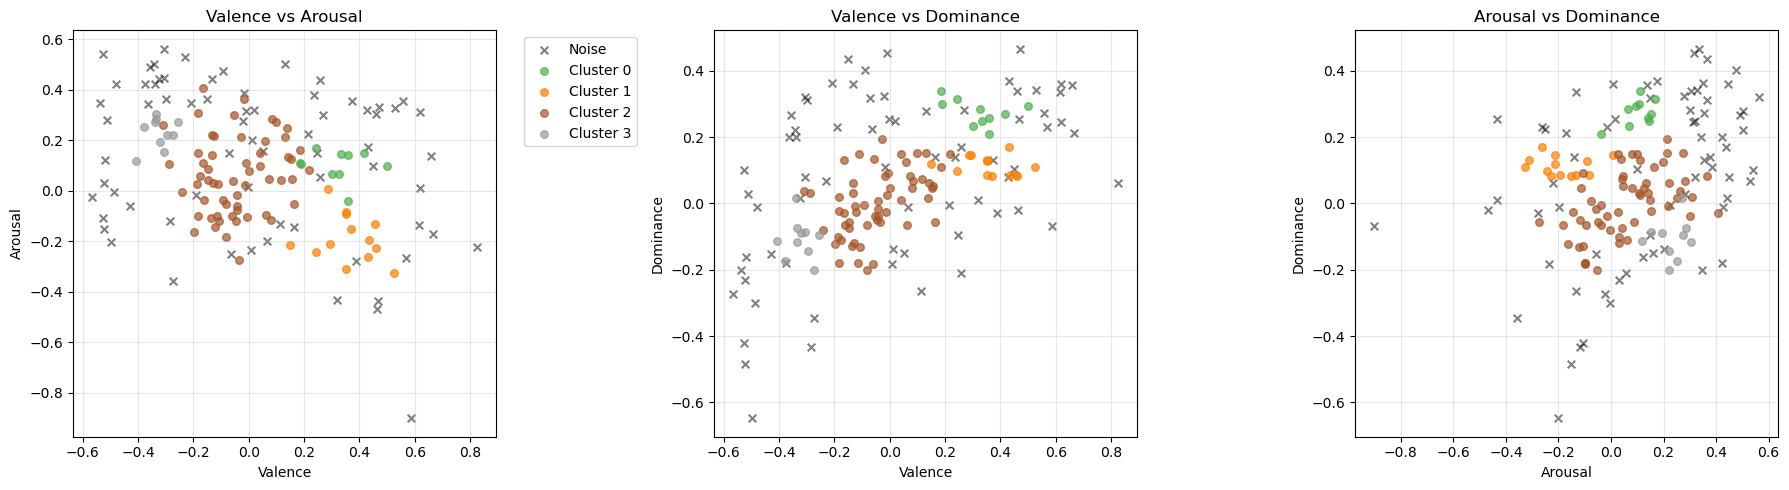

2D projections show how clusters separate in different VAD dimension pairs


In [22]:
# Create 2D projections of the 3D clusters
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define colors for consistency
unique_labels = sorted(set(cluster_labels))
color_map = {}
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))
for i, label in enumerate(unique_labels):
    if label == -1:
        color_map[label] = 'black'
    else:
        color_map[label] = colors[i]

# Valence vs Arousal
ax1 = axes[0]
for label in unique_labels:
    mask = cluster_labels == label
    if label == -1:
        ax1.scatter(vad_features[mask, 0], vad_features[mask, 1], 
                   c=color_map[label], marker='x', alpha=0.5, s=30, label='Noise')
    else:
        ax1.scatter(vad_features[mask, 0], vad_features[mask, 1], 
                   c=color_map[label], alpha=0.7, s=30, label=f'Cluster {label}')
ax1.set_xlabel('Valence')
ax1.set_ylabel('Arousal')
ax1.set_title('Valence vs Arousal')
ax1.grid(True, alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Valence vs Dominance  
ax2 = axes[1]
for label in unique_labels:
    mask = cluster_labels == label
    if label == -1:
        ax2.scatter(vad_features[mask, 0], vad_features[mask, 2], 
                   c=color_map[label], marker='x', alpha=0.5, s=30, label='Noise')
    else:
        ax2.scatter(vad_features[mask, 0], vad_features[mask, 2], 
                   c=color_map[label], alpha=0.7, s=30, label=f'Cluster {label}')
ax2.set_xlabel('Valence')
ax2.set_ylabel('Dominance')
ax2.set_title('Valence vs Dominance')
ax2.grid(True, alpha=0.3)

# Arousal vs Dominance
ax3 = axes[2]
for label in unique_labels:
    mask = cluster_labels == label
    if label == -1:
        ax3.scatter(vad_features[mask, 1], vad_features[mask, 2], 
                   c=color_map[label], marker='x', alpha=0.5, s=30, label='Noise')
    else:
        ax3.scatter(vad_features[mask, 1], vad_features[mask, 2], 
                   c=color_map[label], alpha=0.7, s=30, label=f'Cluster {label}')
ax3.set_xlabel('Arousal')
ax3.set_ylabel('Dominance')
ax3.set_title('Arousal vs Dominance')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("2D projections show how clusters separate in different VAD dimension pairs")
